In [10]:
import os
import gc
import glob

from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
from scipy.spatial.distance import pdist
from scipy.cluster.hierarchy import linkage, to_tree

import matplotlib.pyplot as plt

from pycirclize import Circos
from pycirclize.utils import ColorCycler

import seaborn as sns

import anndata as ad
import scanpy as sc

%matplotlib inline

In [14]:
## Read In Data ##

adata = sc.read_h5ad('/mnt/sdb/scz_meta_analysis_processed/anndata_objs/integrated_adata_annotated_w_celltypist_scanvi.h5ad')

## Toss Stressed Glia & Doublets ##

adata = adata[~(adata.obs['subclass_annotations'] == 'Stressed Glia') & ~adata.obs['pred_dbl']].copy()
gc.collect()

# Note Stressed Glia is not large enough for statistical testing, 
#adata[adata.obs['subclass_annotations'] == 'Stressed Glia'].shape[0]
# 858 # despite contribution from multiple donors, manuscripts but dominated by Walsh/Studer MEL-1 line

9406

In [15]:
## Refrorm Categories as Str For Proper Coloring ##

adata.obs['subclass_annotations'] = adata.obs['subclass_annotations'].astype('str')
adata.obs['subclass_annotations_markers'] = adata.obs['subclass_annotations_markers'].astype('str')
adata.obs['subtype_cluster_annotations'] = adata.obs['subtype_cluster_annotations'].astype('str')
adata.obs['subtype_cluster_annotations_markers'] = adata.obs['subtype_cluster_annotations_markers'].astype('str')

In [173]:
## Correct CP / Choroid Plexus Distinction ##

adata.obs['subtype_cluster_annotations'] = adata.obs['subtype_cluster_annotations'].str.replace('Choroid Plexus ', 'CP-')
adata.obs['subtype_cluster_annotations_markers'] = adata.obs['subtype_cluster_annotations_markers'].str.replace('Choroid Plexus ', 'CP-')

In [16]:
subclass_markers_order = ['Proliferative Radial Glia SOX2+HES6+TOP2A+', 'Radial Glia SOX2+PAX6+FABP7+', 
                          'Radial Glia SOX2+VIM+FABP7+', 'Hindbrain Neurons NR2F2+PBX3+LHX1+', 'Mixed Neurons FGF12+GRIN2B+CAMK2B+', 
                          'GABAergic GAD1+GAD2+CALB2+', 'Dorsal Forebrain Neuron FOXG1+EMX1+NEUROG1+',
                          'Mesenchymal-like cells VIM+VCAN+SPARC+']

# Make the 'subclass_annotations_markers' column a categorical type with the custom order
adata.obs['subclass_annotations_markers'] = pd.Categorical(adata.obs['subclass_annotations_markers'], 
                                                           categories=subclass_markers_order, ordered=True)

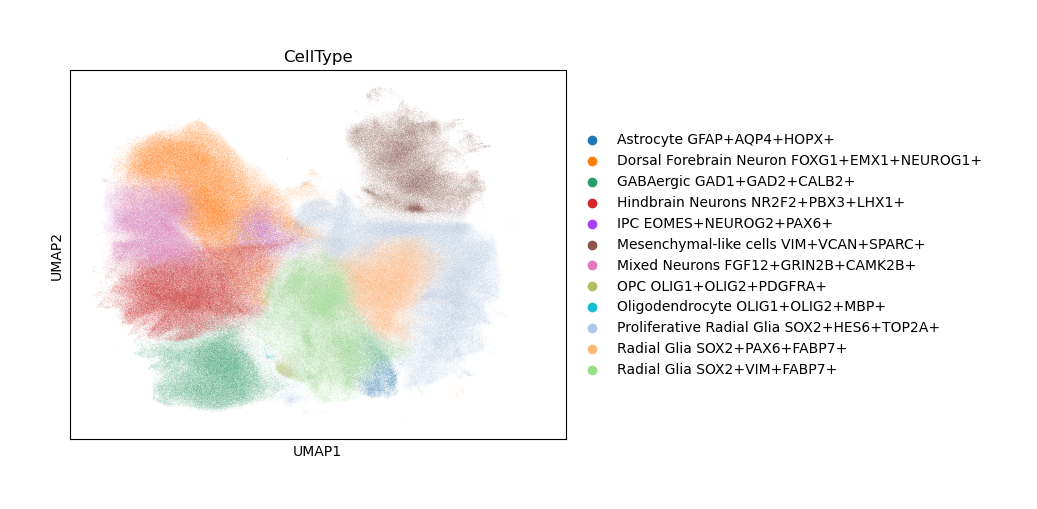

In [32]:
sc.pl.umap(adata, color='CellType')

In [105]:
adata.obs[['CellType', 'subtype_cluster_annotations', 'Donor']].value_counts()

CellType                                     subtype_cluster_annotations      Donor    
Hindbrain Neurons NR2F2+PBX3+LHX1+           Hindbrain/Cerebellar EN          MEL-1        45944
Dorsal Forebrain Neuron FOXG1+EMX1+NEUROG1+  Upper Layer Neuron Transitional  MEL-1        24699
                                             Deep Layer Neuron                2607         20983
Mesenchymal-like cells VIM+VCAN+SPARC+       Neurogenic RG                    MH0159020    18003
Hindbrain Neurons NR2F2+PBX3+LHX1+           Hypothalamic EN                  H1           17739
                                                                                           ...  
GABAergic GAD1+GAD2+CALB2+                   Immature CGE Interneuron         60C2             1
Dorsal Forebrain Neuron FOXG1+EMX1+NEUROG1+  Stressed Neuron                  DT1_U            1
Mesenchymal-like cells VIM+VCAN+SPARC+       Schwann Cell                     WTC11            1
Radial Glia SOX2+VIM+FABP7+            

In [131]:

import matplotlib.pyplot as plt
import os

def plot_circos_layers(
    adata,
    outer_col,
    track_layout,   # list of (column, thickness)
    cmaps=None,
    spacing=1,
    outer_thickness=4,
    sector_space=1,
    outer_label=True,
    legend=False,
    savefig=False
):
    """
    Advanced circos plot with full layout + legend + saving control.
    """

    # -----------------------------
    # Outer sectors
    # -----------------------------
    ct_counts = adata.obs[outer_col].value_counts()
    sectors = ct_counts.to_dict()
    circos = Circos(sectors, space=sector_space)

    # -----------------------------
    # Default colormaps
    # -----------------------------
    if cmaps is None:
        cmaps = ["tab20", "Set2", "tab20b", "Set3", "Pastel1"]

    if len(cmaps) < len(track_layout):
        cmaps = (cmaps * (len(track_layout)//len(cmaps)+1))[:len(track_layout)]

    # -----------------------------
    # Build mappings + color maps
    # -----------------------------
    layer_mappings = {}
    layer_colors = {}

    for i, (col, _) in enumerate(track_layout):
        vc = adata.obs[[outer_col, col]].value_counts()
        mapping = defaultdict(list)

        for (ct, sub), count in vc.items():
            mapping[ct].append((sub, count))

        for ct in mapping:
            mapping[ct].sort(key=lambda x: x[1], reverse=True)

        layer_mappings[col] = mapping

        # global color map (important for legend consistency)
        unique_vals = adata.obs[col].dropna().unique()
        ColorCycler.set_cmap(cmaps[i])
        layer_colors[col] = {
            val: ColorCycler() for val in unique_vals
        }

    # -----------------------------
    # Draw layers
    # -----------------------------
    current_r = 70

    for i, (col, thickness) in enumerate(track_layout):
        r0 = current_r
        r1 = r0 + thickness

        for sector in circos.sectors:
            track = sector.add_track((r0, r1))

            start = 0
            for label, count in layer_mappings[col][sector.name]:
                track.rect(
                    start=start,
                    end=start + count,
                    fc=layer_colors[col].get(label, "grey"),
                    ec=None
                )
                start += count

        current_r = r1 + spacing

    # -----------------------------
    # Outer ring
    # -----------------------------
    outer_r0 = current_r
    outer_r1 = outer_r0 + outer_thickness

    ColorCycler.set_cmap("tab20")

    for sector in circos.sectors:
        circos.rect(
            r_lim=(outer_r0, outer_r1),
            deg_lim=sector.deg_lim,
            fc=ColorCycler(),
            ec="black",
            lw=0.5
        )

        if outer_label:
            center_deg = sum(sector.deg_lim) / 2
            circos.text(
                str(sector.name).split()[0],
                r=outer_r1 + 4,
                deg=center_deg,
                adjust_rotation=True,
                size=8
            )

    fig = circos.plotfig()

    # -----------------------------
    # Legend (optional)
    # -----------------------------
    if legend:
        handles = []
        labels = []

        for col in layer_colors:
            for k, v in layer_colors[col].items():
                handles.append(plt.Rectangle((0,0),1,1, color=v))
                labels.append(f"{col}: {k}")

        fig.legend(
            handles,
            labels,
            loc="center left",
            bbox_to_anchor=(1.05, 0.5),
            fontsize=6
        )

    # -----------------------------
    # Savefig (optional)
    # -----------------------------
    if savefig:
        base = "/home/deepak/datasets/scz_meta_analysis/panels/"
        os.makedirs(base, exist_ok=True)

        png_path = os.path.join(base, f"{savefig}.png")
        svg_path = os.path.join(base, f"{savefig}.svg")

        fig.savefig(png_path, bbox_inches="tight", dpi=300)
        fig.savefig(svg_path, bbox_inches="tight")

    return fig, circos

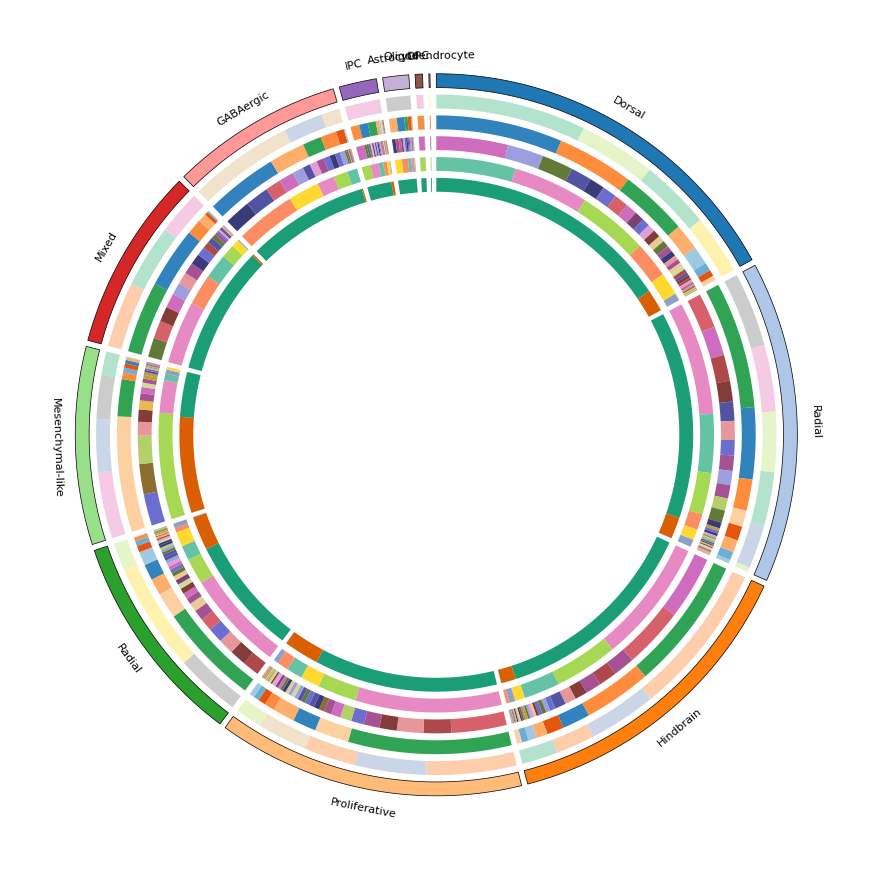

In [133]:
fig, circos = plot_circos_layers(
    adata,
    outer_col="CellType",
    sector_space=1,
    track_layout=[
        ("Chemistry", 4),
        ("Protocol", 4),
        ("Donor", 4),
        ("Manuscript", 4),
        ("subtype_cluster_annotations", 4),
    ],
    spacing=2,
    legend=False,
    cmaps = ["Dark2", "Set2", "tab20b",  "tab20c", "Pastel2"], savefig=False)

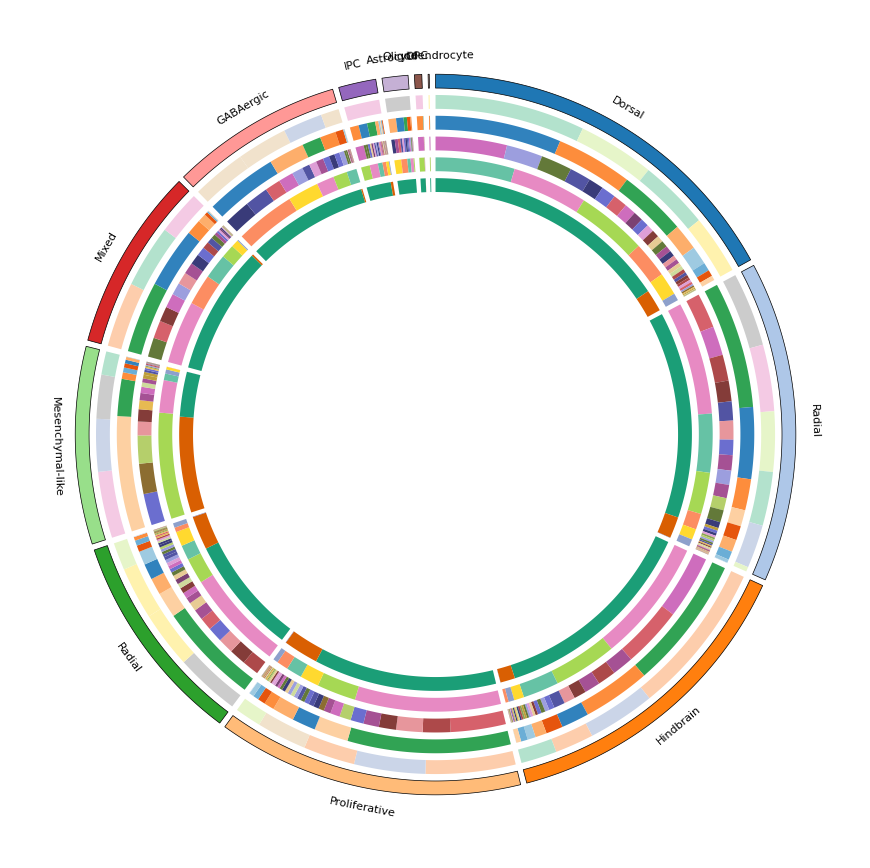

In [140]:
fig, circos = plot_circos_layers(
    adata,
    outer_col="CellType",
    sector_space=1,
    track_layout=[
        ("Chemistry", 4),
        ("Protocol", 4),
        ("Donor", 4),
        ("Manuscript", 4),
        ("subtype_cluster_annotations", 4),
    ],
    spacing=2,
    legend=False,
    cmaps = ["Dark2", "Set2", "tab20b",  "tab20c", "Pastel2"], 
    savefig="Figure_1_Circos_All_Layers")

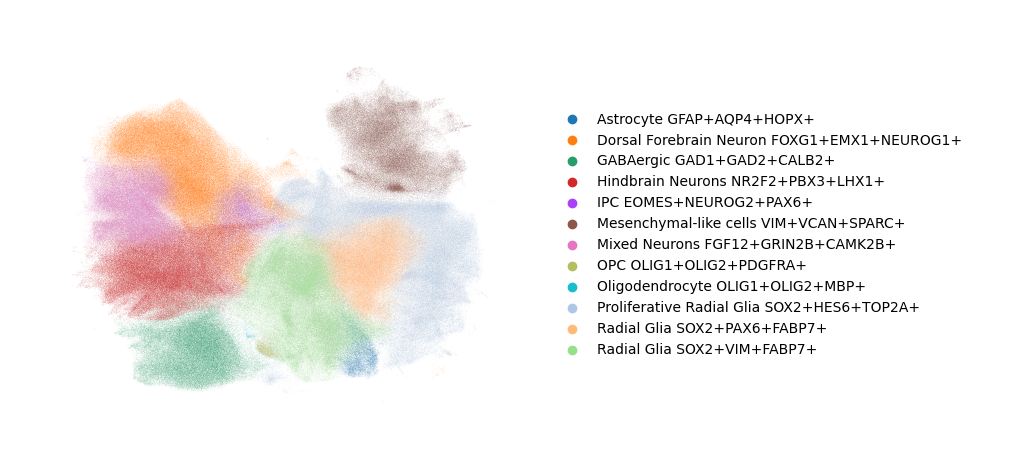

In [127]:
fig, ax = plt.subplots()

sc.pl.umap(adata, color='CellType', ax=ax, show=False)

# Remove axis labels
ax.set_xlabel('')
ax.set_ylabel('')

# Remove title
ax.set_title('')

# Remove border (spines) and ticks
for spine in ax.spines.values():
    spine.set_visible(False)

ax.set_xticks([])
ax.set_yticks([])

plt.savefig("/home/deepak/datasets/scz_meta_analysis/panels/Fig_1_CellType_UMAP.svg", dpi=300, bbox_inches="tight")
plt.show()

In [493]:
celltype_dge_list = []
for file_path in glob.glob('/mnt/sdb/scz_meta_analysis_processed/dge_signatures/dreamlet_dges/one_vs_all/CellType/DE_*'):
    dge = pd.read_csv(file_path, index_col=0)
    celltype_dge_list.append(dge)

celltype_dges = pd.concat(celltype_dge_list, axis=0)

celltype_dges.rename({'class':'CellType'}, axis=1, inplace=True)

celltype_dges['neglogP'] = -np.log10(celltype_dges['adj.P.Val'] )

In [516]:
plot_df['CellType'].isnull().sum()

18486

In [521]:
celltype_dges['CellType'].unique().tolist()

['Proliferative Radial Glia SOX2+HES6+TOP2A+',
 'Stressed Glia FTL+B2M+GLUL+',
 'Dorsal Forebrain Neuron FOXG1+EMX1+NEUROG1+',
 'Radial Glia SOX2+VIM+FABP7+',
 'Mixed Neurons FGF12+GRIN2B+CAMK2B+',
 'Oligodendrocyte OLIG1+OLIG2+MBP+',
 'OPC OLIG1+OLIG2+PDGFRA+',
 'GABAergic GAD1+GAD2+CALB2+',
 'IPC EOMES+NEUROG2+PAX6+',
 'Astrocyte GFAP+AQP4+HOPX+',
 'Radial Glia SOX2+PAX6+FABP7+',
 'Hindbrain Neurons NR2F2+PBX3+LHX1+',
 'Mesenchymal-like cells VIM+VCAN+SPARC+']

In [514]:
subclass_clusters = ['Proliferative Radial Glia SOX2+HES6+TOP2A+',
 'Radial Glia SOX2+VIM+FABP7+',
 'Radial Glia SOX2+PAX6+FABP7+',
 'IPC EOMES+NEUROG2+PAX6+',
 'Mixed Neurons FGF12+GRIN2B+CAMK2B+',
 'Hindbrain Neurons NR2F2+PBX3+LHX1+',
 'GABAergic GAD1+GAD2+CALB2+',
 'Mesenchymal-like cells VIM+VCAN+SPARC+',
 'Dorsal Forebrain Neuron FOXG1+EMX1+NEUROG1+',
 'OPC OLIG1+OLIG2+PDGFRA+',
 'Oligodendrocyte OLIG1+OLIG2+MBP+',
 'Astrocyte GFAP+AQP4+HOPX+']


# Prep Plot #

plot_df = celltype_dges[['logFC', 'neglogP', 'CellType']].copy()

plot_df['gene'] = plot_df.index  
plot_df['CellType'] = pd.Categorical(plot_df['CellType'], categories=subclass_clusters, ordered=True)
# plot_df = plot_df.sort_values(by='CellType') 

# gene_order = plot_df['CellType'].str.split(' ').apply(lambda x: x[-1]).str.strip('+').str.split('+').explode().unique().tolist()
# gene_order.reverse()

# plot_df['gene'] = pd.Categorical(plot_df['gene'], categories=gene_order, ordered=True)

# # useful genes
# plot_df = plot_df[plot_df['gene'].isin(gene_order)]

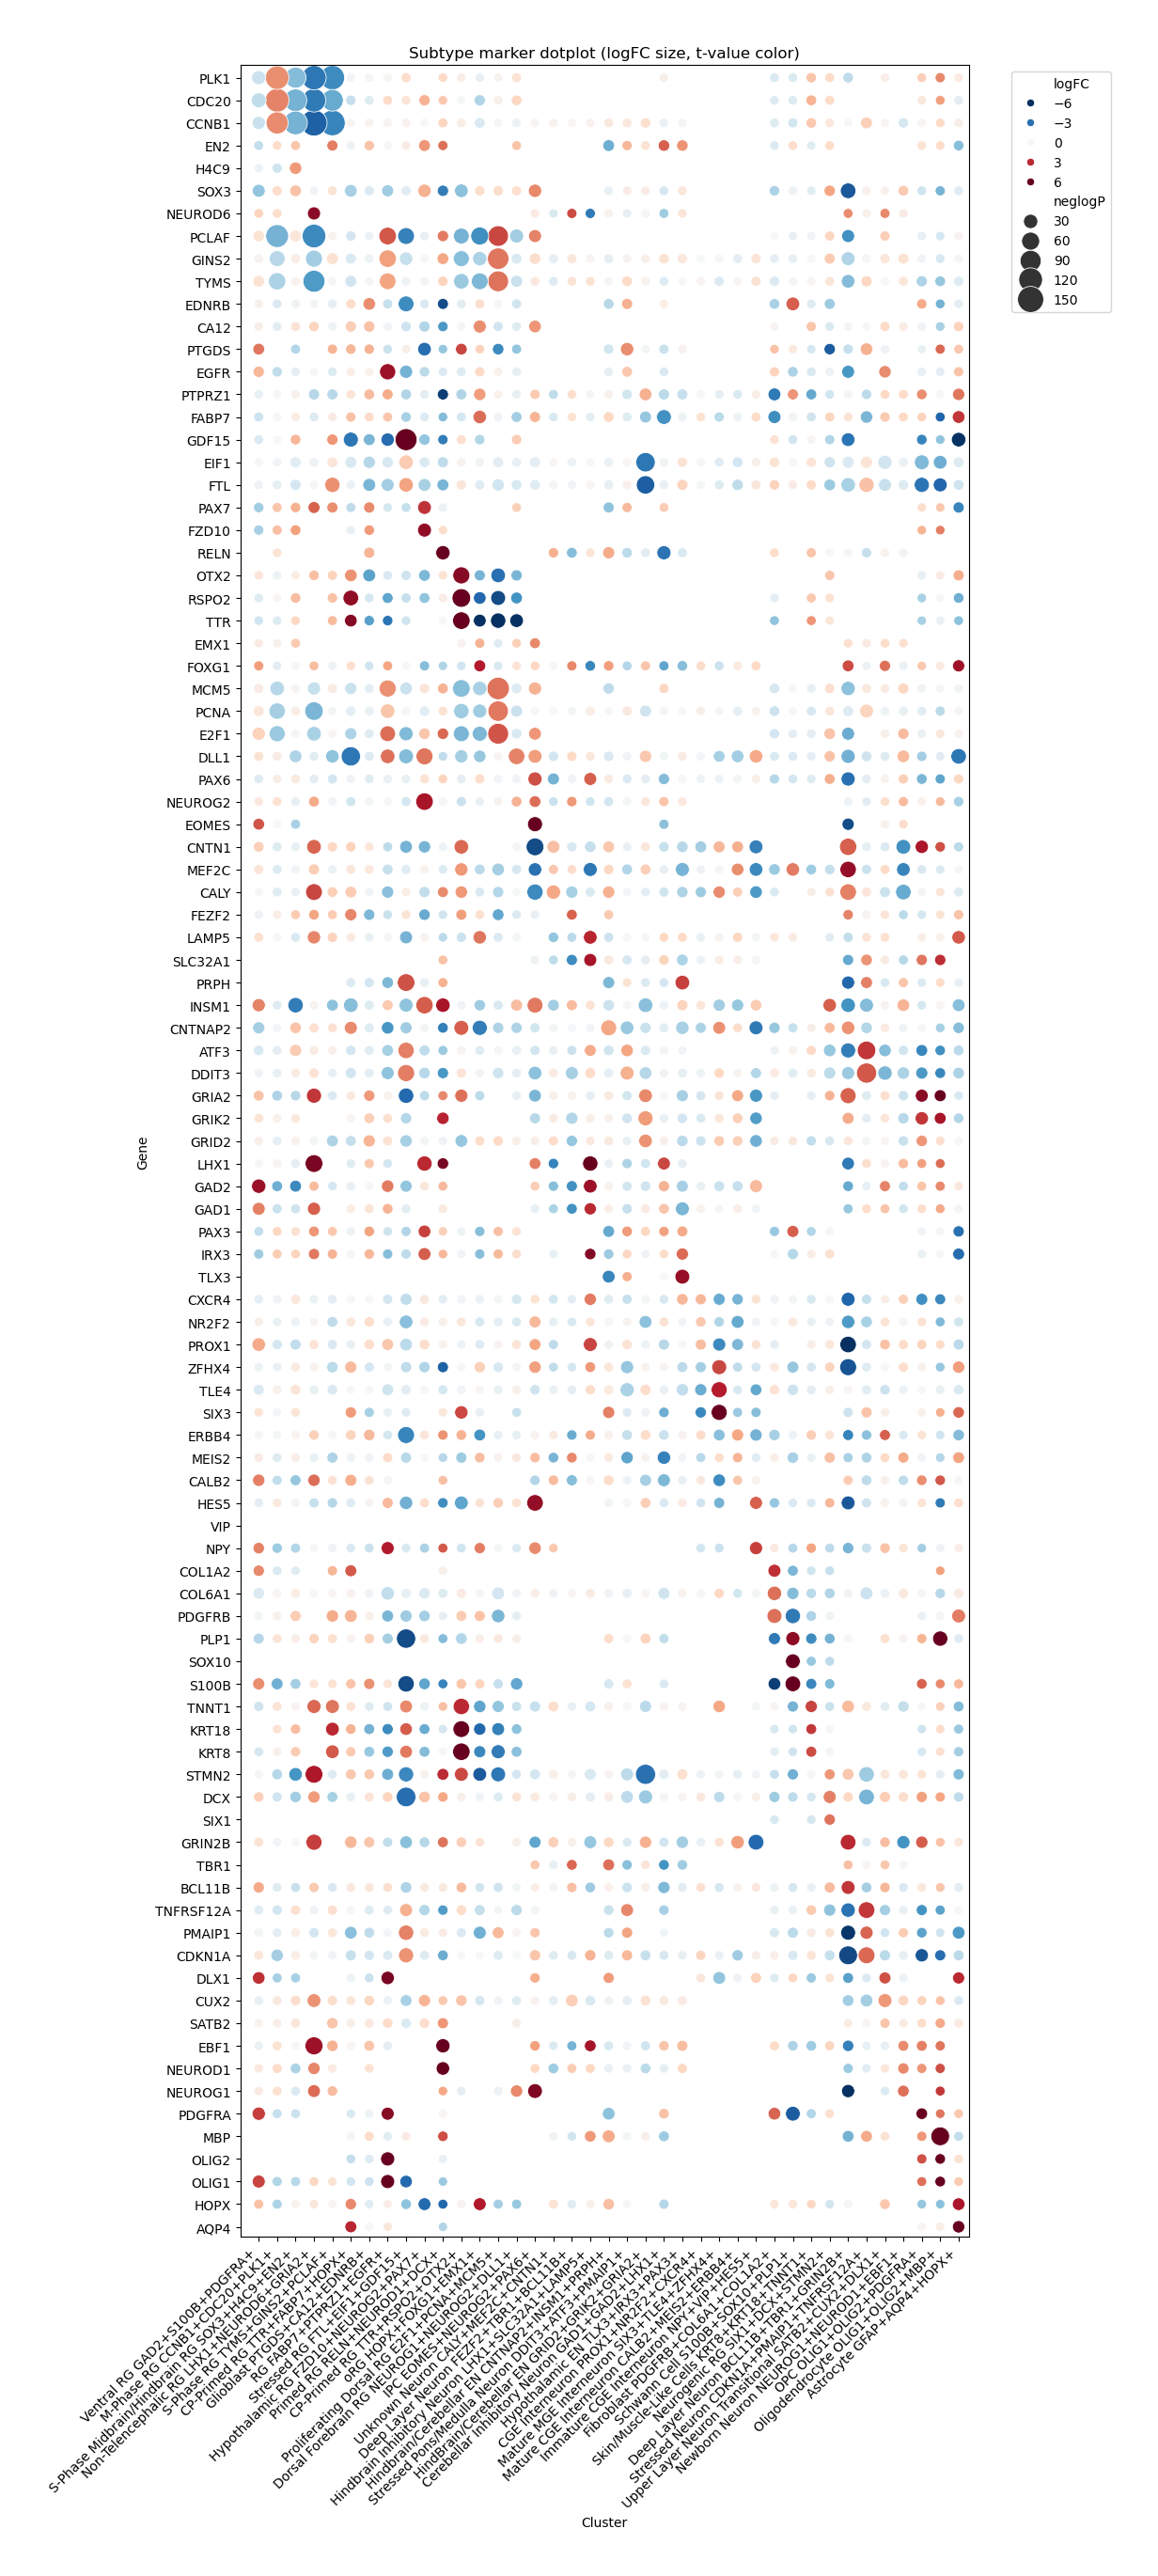

In [464]:
plt.figure(figsize=(10, 30))

sns.scatterplot(
    data=plot_df,
    x='CellType',
    y='gene',
    size='neglogP',
    hue='logFC',
    palette='RdBu_r',
    hue_norm=(-4, 4),
    sizes=(50, 400))
 #   edgecolor='black')

plt.xticks(rotation=45, ha='right')
plt.xlabel("Cluster")
plt.ylabel("Gene")
plt.title("Subtype marker dotplot (logFC size, t-value color)")

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.ylim(len(plot_df['gene'].unique()) - 0.55, -0.55)
plt.xlim(len(plot_df['cluster'].unique()) - 0, -0.55)
plt.show()

In [465]:
cluster_order.reverse()
gene_order.reverse()

plot_df['cluster'] = pd.Categorical(plot_df['cluster'], categories=cluster_order, ordered=True)
plot_df['gene'] = pd.Categorical(plot_df['gene'], categories=gene_order, ordered=True)

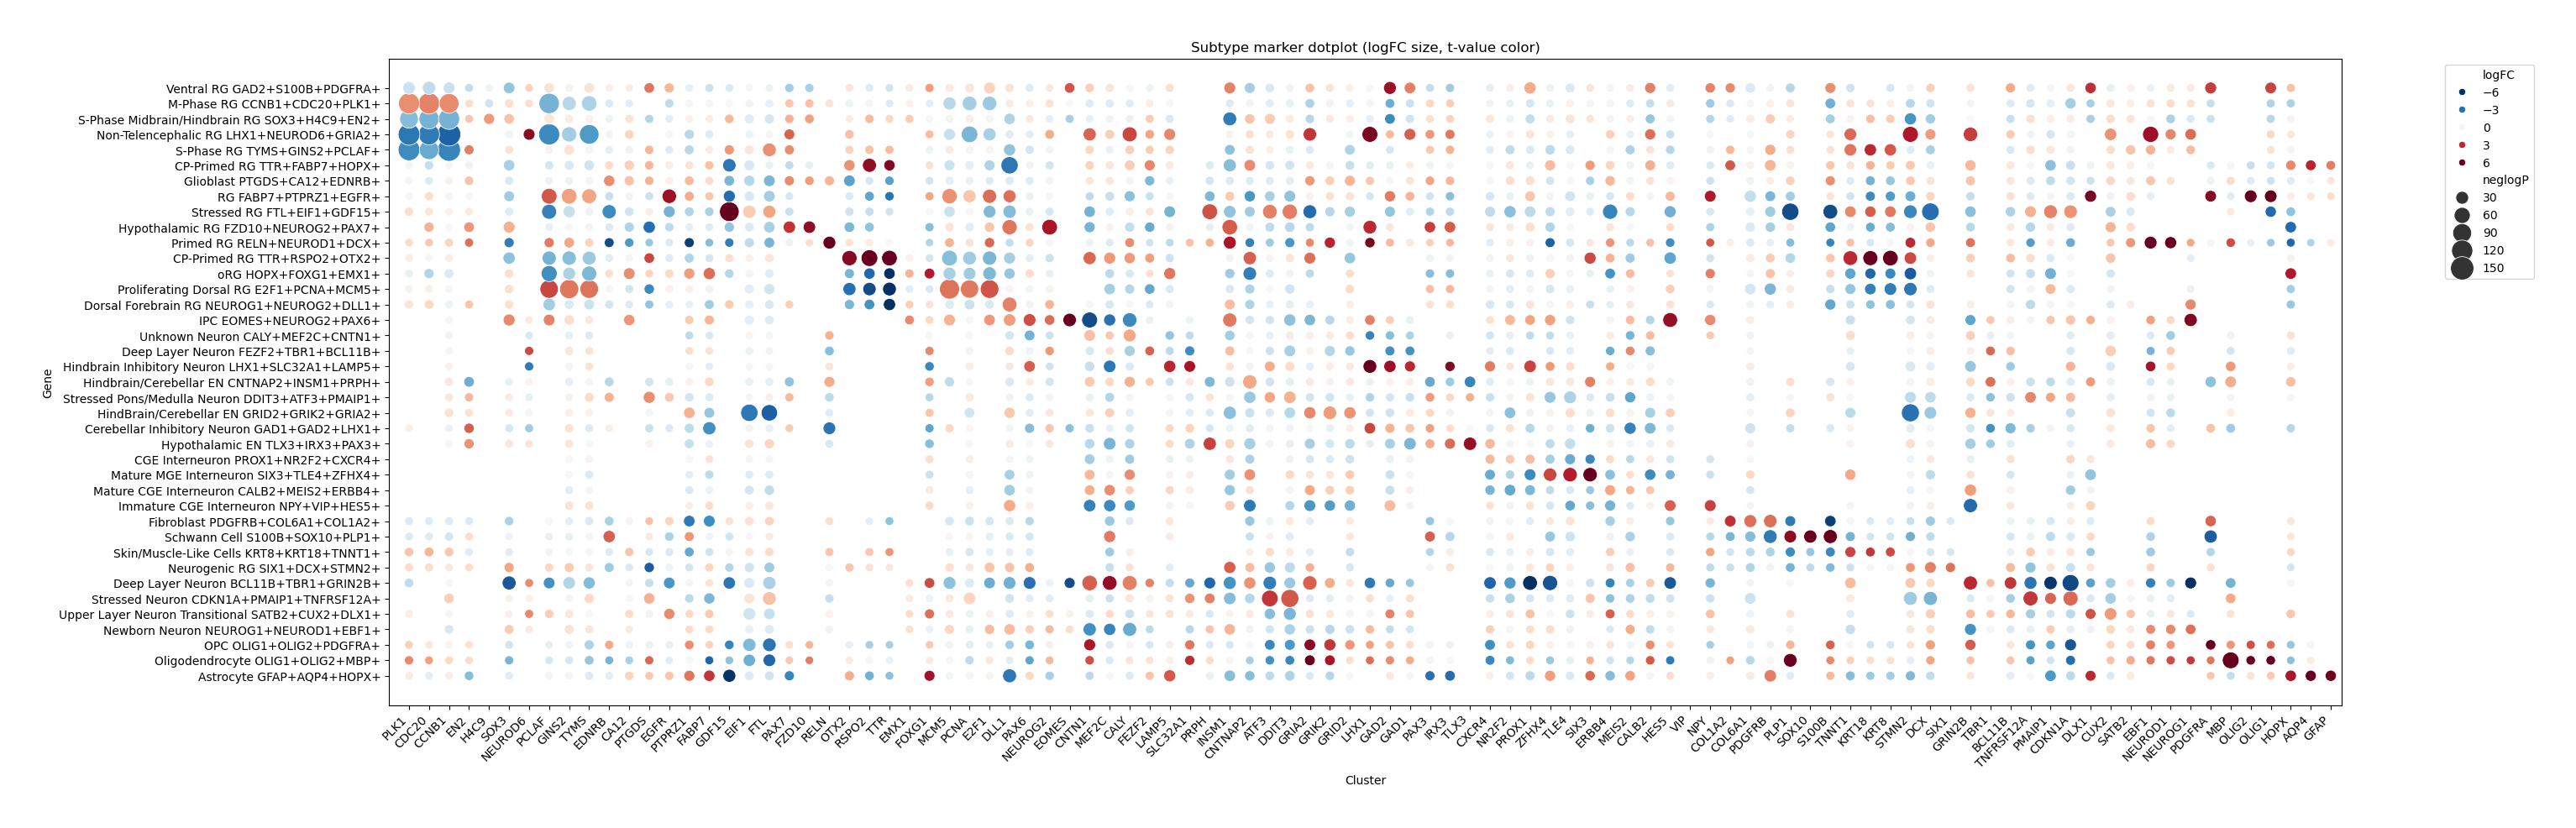

In [478]:
plt.figure(figsize=(30, 10))

sns.scatterplot(
    data=plot_df,
    y='cluster',
    x='gene',
    size='neglogP',
    hue='logFC',
    palette='RdBu_r',
    hue_norm=(-4, 4),
    sizes=(50, 400))
 #   edgecolor='black')

plt.xticks(rotation=45, ha='right')
plt.xlabel("Cluster")
plt.ylabel("Gene")
plt.title("Subtype marker dotplot (logFC size, t-value color)")

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
# plt.ylim(len(plot_df['gene'].unique()) - 0.55, -0.55)
plt.xlim(len(plot_df['gene'].unique()) + 1, -.55)
plt.show()

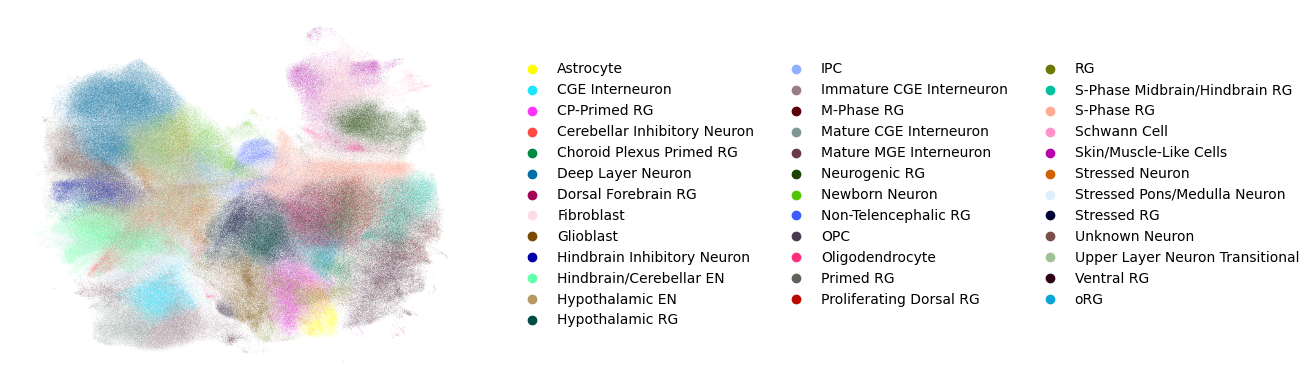

In [7]:
fig, ax = plt.subplots()

sc.pl.umap(adata, color='subtype_cluster_annotations', ax=ax, show=False)

# Remove axis labels
ax.set_xlabel('')
ax.set_ylabel('')

# Remove title
ax.set_title('')

# Remove border (spines) and ticks
for spine in ax.spines.values():
    spine.set_visible(False)

ax.set_xticks([])
ax.set_yticks([])

plt.show()

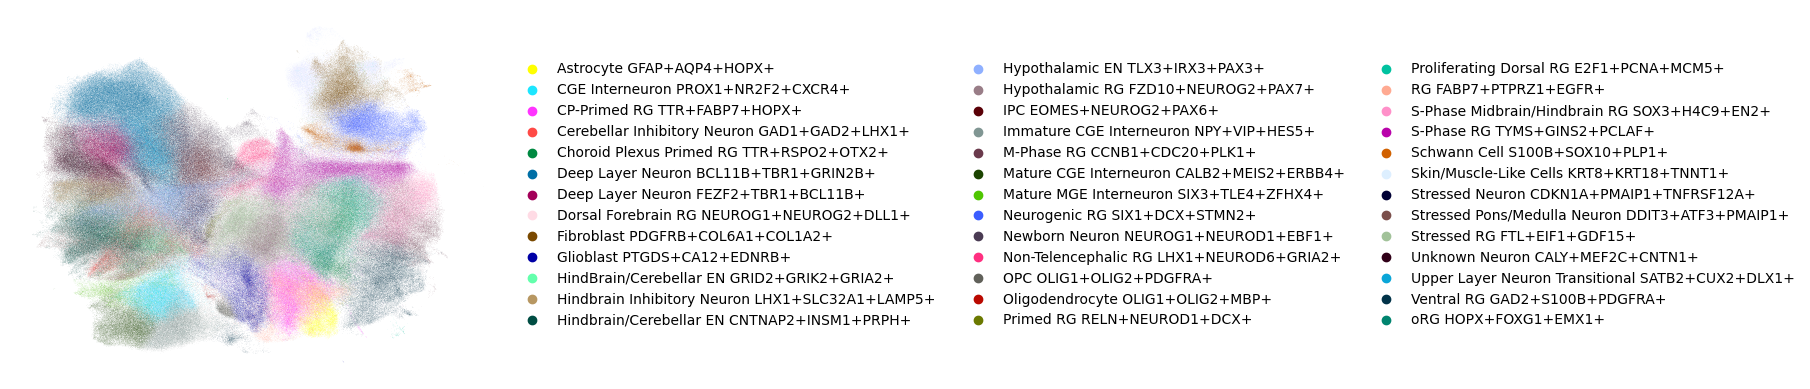

In [8]:
fig, ax = plt.subplots()

sc.pl.umap(adata, color='subtype_cluster_annotations_markers', ax=ax, show=False)

# Remove axis labels
ax.set_xlabel('')
ax.set_ylabel('')

# Remove title
ax.set_title('')

# Remove border (spines) and ticks
for spine in ax.spines.values():
    spine.set_visible(False)

ax.set_xticks([])
ax.set_yticks([])

plt.show()

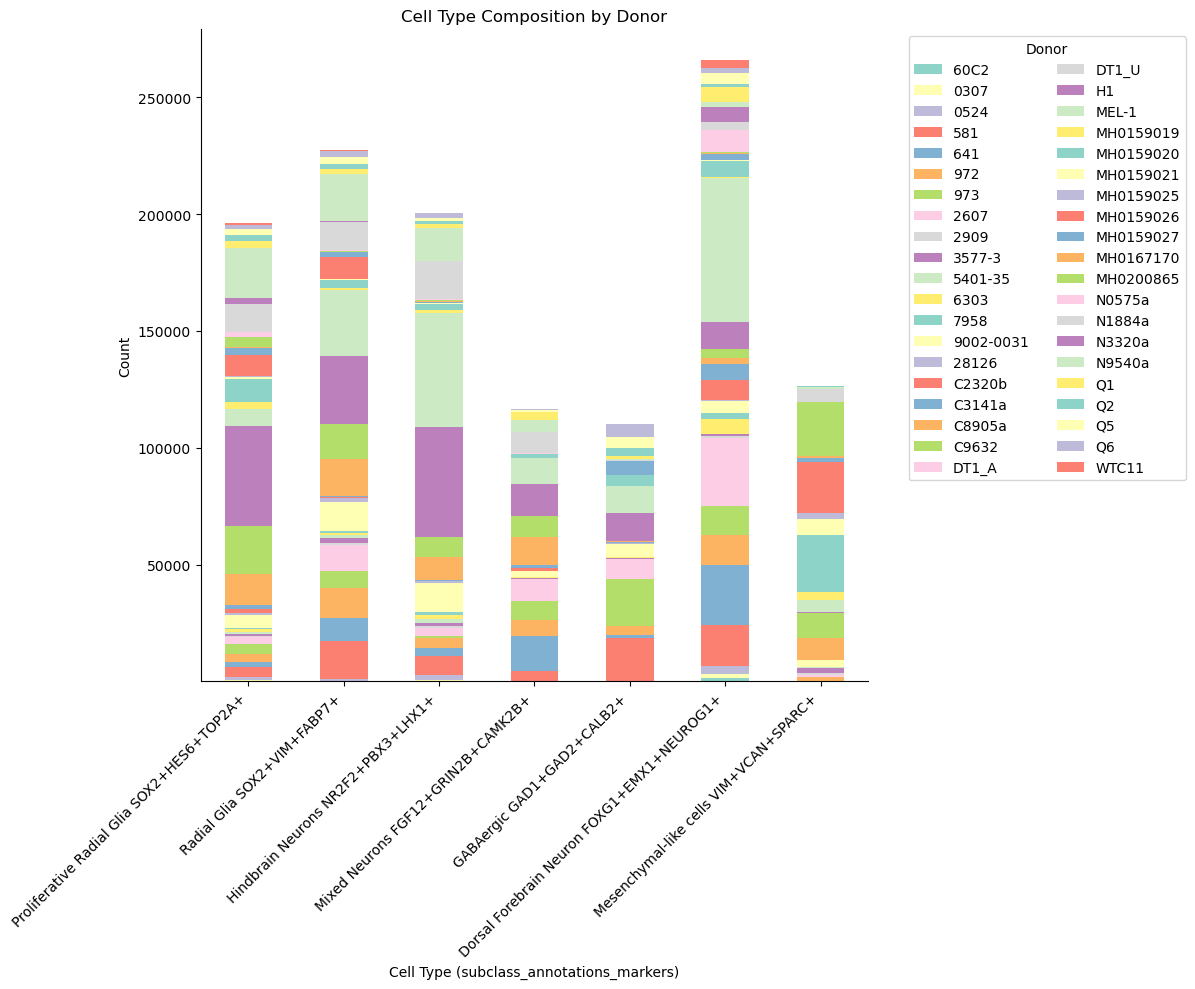

In [9]:
# Create a contingency table (counts of each subclass_annotations_markers per Donor)
contingency_table = pd.crosstab(adata.obs['subclass_annotations_markers'], adata.obs['Donor'])

# Create a color palette with a distinct color for each donor
unique_donors = adata.obs['Donor'].unique()
palette = sns.color_palette("Set3", len(unique_donors))

# Plot a stacked barplot with a taller and skinnier figure
fig, ax = plt.subplots(figsize=(12, 10))  # Increase height, reduce width

# Plot the contingency table as a stacked barplot
contingency_table.plot(kind='bar', stacked=True, color=palette, ax=ax)

# Set plot labels and title
ax.set_xlabel('Cell Type (subclass_annotations_markers)')
ax.set_ylabel('Count')
ax.set_title('Cell Type Composition by Donor')

# Rotate the x-axis labels
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

# Remove the top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Move legend outside the plot and set multiple columns for better readability
ax.legend(title='Donor', bbox_to_anchor=(1.05, 1), loc='upper left', ncol=2)

# Adjust layout to make space for the legend
plt.tight_layout()

# Show plot
plt.show()

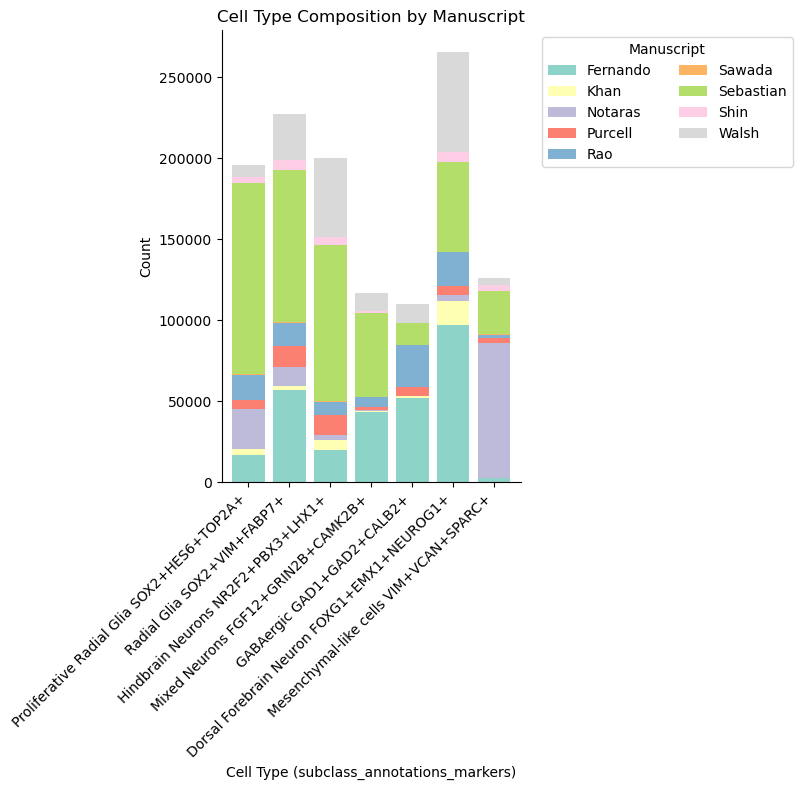

In [10]:
# Create a contingency table (counts of each subclass_annotations_markers per Manuscript)
contingency_table = pd.crosstab(adata.obs['subclass_annotations_markers'], adata.obs['Manuscript'])

# Create a color palette with a distinct color for each Manuscript
unique_manuscripts = adata.obs['Manuscript'].unique()
palette = sns.color_palette("Set3", len(unique_manuscripts))

# Plot a stacked barplot with adjusted bar width and figure size
fig, ax = plt.subplots(figsize=(8, 8))  # Taller figure
contingency_table.plot(kind='bar', stacked=True, color=palette, ax=ax, width=0.8)

# Set plot labels and title
ax.set_xlabel('Cell Type (subclass_annotations_markers)')
ax.set_ylabel('Count')
ax.set_title('Cell Type Composition by Manuscript')

# Rotate the x-axis labels 45 degrees and align them to the right
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

# Move legend outside the plot and set multiple columns for better readability
ax.legend(title='Manuscript', bbox_to_anchor=(1.05, 1), loc='upper left', ncol=2)

# Remove the top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Adjust layout to make space for the legend
plt.tight_layout()

# Show plot
plt.show()

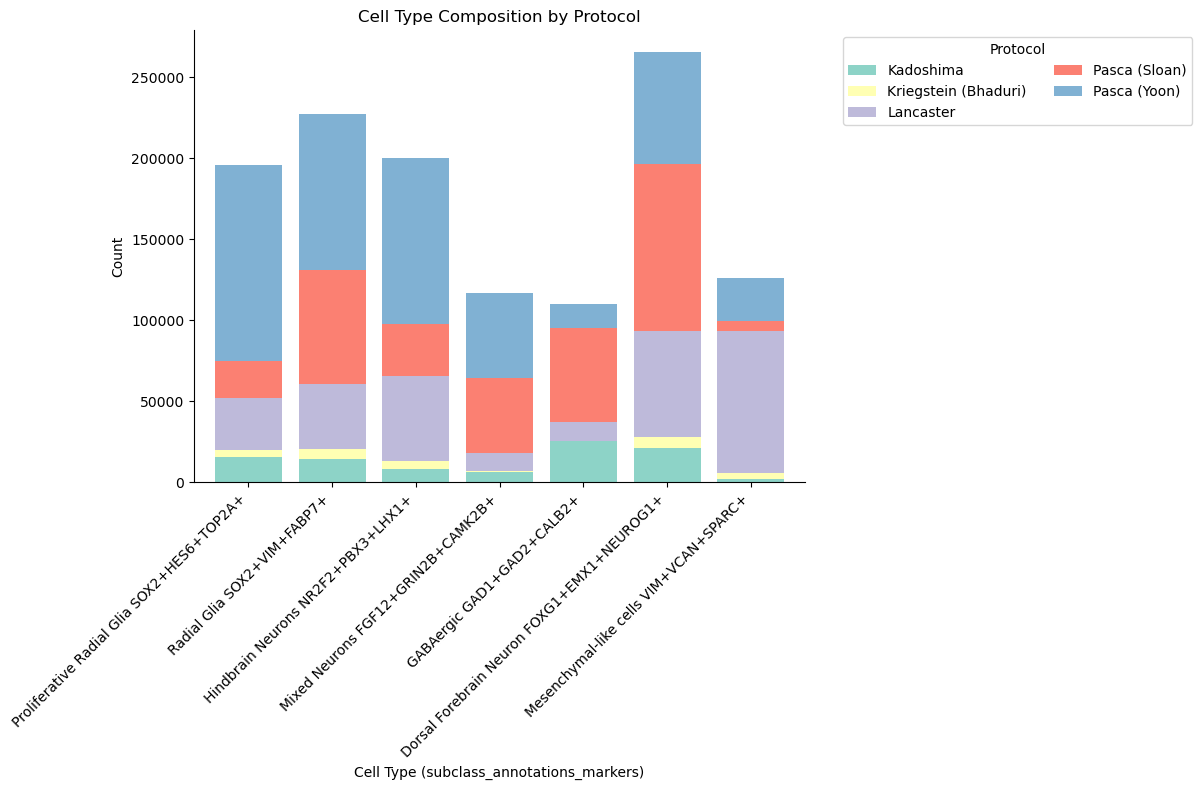

In [11]:
# Create a contingency table (counts of each subclass_annotations_markers per Protocol)
contingency_table = pd.crosstab(adata.obs['subclass_annotations_markers'], adata.obs['Protocol'])

# Create a color palette with a distinct color for each Protocol
unique_protocols = adata.obs['Protocol'].unique()
palette = sns.color_palette("Set3", len(unique_protocols))

# Plot a stacked barplot with adjusted bar width and figure size
fig, ax = plt.subplots(figsize=(12, 8))  # Taller figure
contingency_table.plot(kind='bar', stacked=True, color=palette, ax=ax, width=0.8)

# Set plot labels and title
ax.set_xlabel('Cell Type (subclass_annotations_markers)')
ax.set_ylabel('Count')
ax.set_title('Cell Type Composition by Protocol')

# Rotate the x-axis labels 45 degrees and align them to the right
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

# Move legend outside the plot and set multiple columns for better readability
ax.legend(title='Protocol', bbox_to_anchor=(1.05, 1), loc='upper left', ncol=2)

# Remove the top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Adjust layout to make space for the legend
plt.tight_layout()

# Show plot
plt.show()

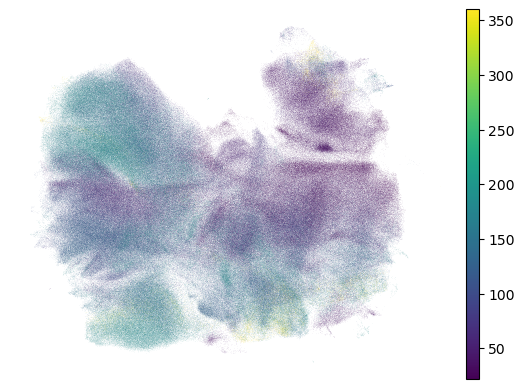

In [12]:
fig, ax = plt.subplots()

sc.pl.umap(adata, color='Day', ax=ax, show=False)

# Remove axis labels
ax.set_xlabel('')
ax.set_ylabel('')

# Remove title
ax.set_title('')

# Remove border (spines) and ticks
for spine in ax.spines.values():
    spine.set_visible(False)

ax.set_xticks([])
ax.set_yticks([])

plt.show()

/tmp/ipykernel_86721/3375115305.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


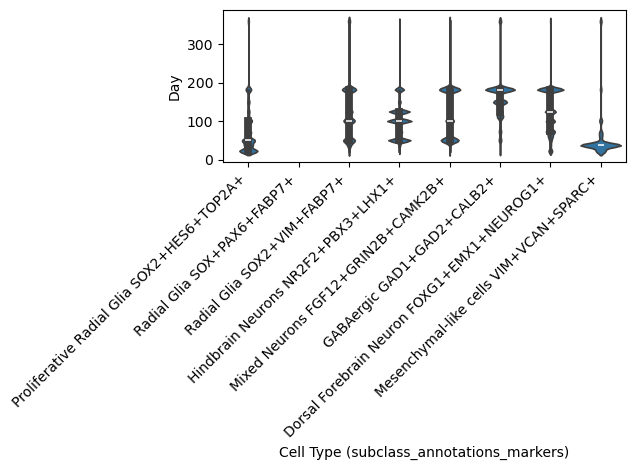

In [13]:
# Create the violin plot
ax = sns.violinplot(data=adata.obs, x='subclass_annotations_markers', y='Day')

# Rotate x-axis labels and set horizontal alignment
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

# Set plot labels and title (optional, for better readability)
ax.set_xlabel('Cell Type (subclass_annotations_markers)')
ax.set_ylabel('Day')

# Show plot
plt.tight_layout()
plt.show()

/tmp/ipykernel_86721/1139319225.py:25: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(
/tmp/ipykernel_86721/1139319225.py:36: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')


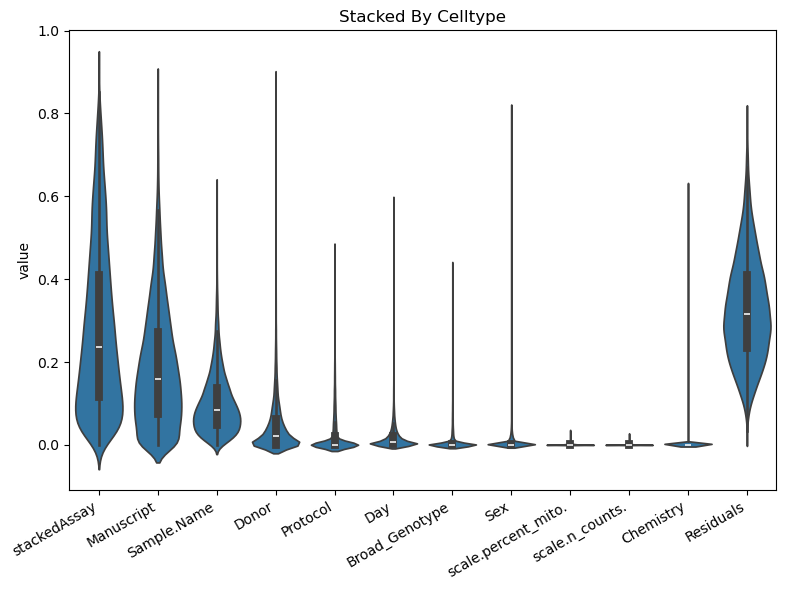

In [14]:
## Variance Partition ##

## generally and for mixing ##
DREAMLET_PATH = '/mnt/sdb/scz_meta_analysis_processed/dge_signatures/dreamlet_dges/disease_analyses/'
stacked_df = pd.read_csv(Path(DREAMLET_PATH) / 'variance_partition_long_stacked.csv')

vp_adaptive_melted = pd.melt(stacked_df, id_vars='gene')

vp_adaptive_melted = vp_adaptive_melted[vp_adaptive_melted['variable'] != 'assay']

# Step 1: Compute mean values (excluding 'residuals')
means = (
    vp_adaptive_melted[vp_adaptive_melted['variable'] != 'Residuals']
    .groupby('variable')['value']
    .mean()
    .sort_values(ascending=False)
)

# Step 2: Create new order: sorted variables + 'residuals' at the end
new_order = list(means.index) + ['Residuals']

# Step 3: Plot with ordered categories
fig, ax = plt.subplots(figsize=(8, 6))
plt.title('Stacked By Celltype')
sns.violinplot(
    data=vp_adaptive_melted,
    x='variable',
    y='value',
    scale='width',
    order=new_order,
    ax=ax
)
plt.xlabel('')

# Step 4: Rotate and align tick labels
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')

plt.tight_layout()
plt.show()

In [17]:
import glob
glob.glob('/mnt/sdb/scz_meta_analysis_processed/dge_signatures/dreamlet_dges/disease_analyses/*scvi*')

['/mnt/sdb/scz_meta_analysis_processed/dge_signatures/dreamlet_dges/disease_analyses/scvi_space_visualize_variance_full.png',
 '/mnt/sdb/scz_meta_analysis_processed/dge_signatures/dreamlet_dges/disease_analyses/scvi_space_variance_partition_long.csv']

/tmp/ipykernel_86721/3987514323.py:26: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(
/tmp/ipykernel_86721/3987514323.py:37: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')


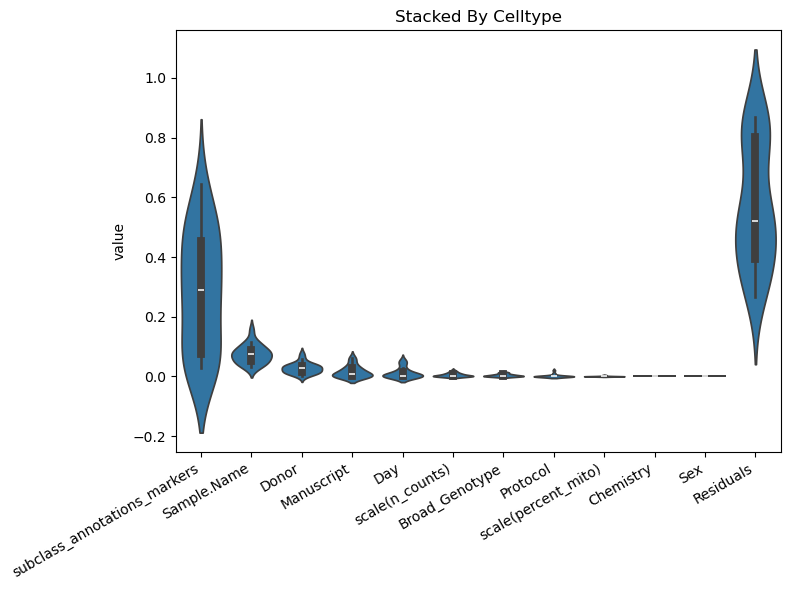

In [23]:
## Variance Partition ##

## generally and for mixing ##
DREAMLET_PATH = '/mnt/sdb/scz_meta_analysis_processed/dge_signatures/dreamlet_dges/disease_analyses/'
stacked_df = pd.read_csv(Path(DREAMLET_PATH) / 'scvi_space_variance_partition_long.csv')

stacked_df['latent_dim'] = pd.Series(np.arange(0,20))
vp_adaptive_melted = pd.melt(stacked_df, id_vars='latent_dim')

vp_adaptive_melted = vp_adaptive_melted[vp_adaptive_melted['variable'] != 'assay']

# Step 1: Compute mean values (excluding 'residuals')
means = (
    vp_adaptive_melted[vp_adaptive_melted['variable'] != 'Residuals']
    .groupby('variable')['value']
    .mean()
    .sort_values(ascending=False)
)

# Step 2: Create new order: sorted variables + 'residuals' at the end
new_order = list(means.index) + ['Residuals']

# Step 3: Plot with ordered categories
fig, ax = plt.subplots(figsize=(8, 6))
plt.title('Stacked By Celltype')
sns.violinplot(
    data=vp_adaptive_melted,
    x='variable',
    y='value',
    scale='width',
    order=new_order,
    ax=ax
)
plt.xlabel('')

# Step 4: Rotate and align tick labels
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')

plt.tight_layout()
plt.show()

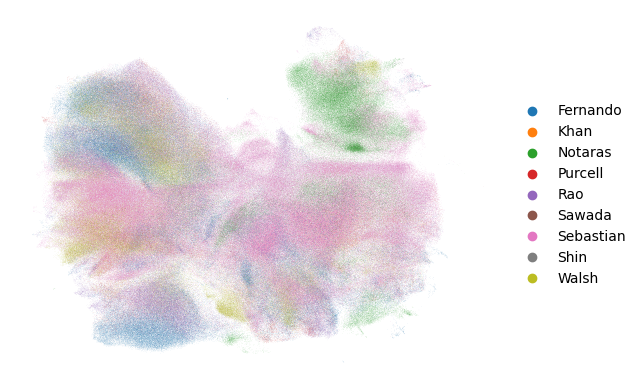

In [24]:
fig, ax = plt.subplots()

sc.pl.umap(adata, color='Manuscript', ax=ax, show=False)

# Remove axis labels
ax.set_xlabel('')
ax.set_ylabel('')

# Remove title
ax.set_title('')

# Remove border (spines) and ticks
for spine in ax.spines.values():
    spine.set_visible(False)

ax.set_xticks([])
ax.set_yticks([])

plt.show()

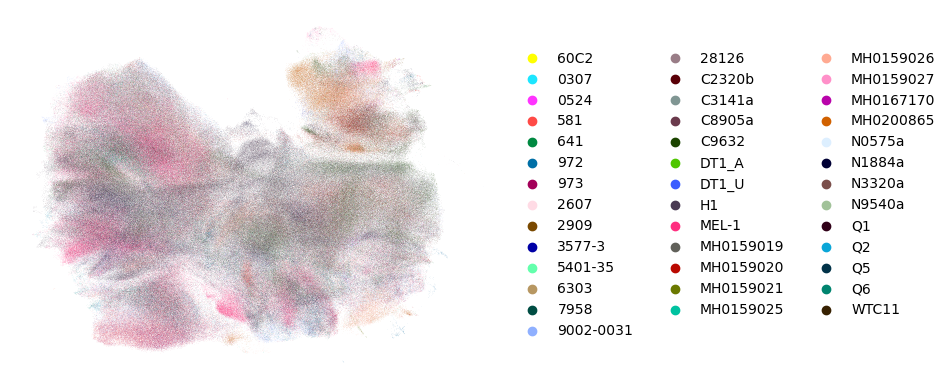

In [25]:
fig, ax = plt.subplots()

sc.pl.umap(adata, color='Donor', ax=ax, show=False)

# Remove axis labels
ax.set_xlabel('')
ax.set_ylabel('')

# Remove title
ax.set_title('')

# Remove border (spines) and ticks
for spine in ax.spines.values():
    spine.set_visible(False)

ax.set_xticks([])
ax.set_yticks([])

plt.show()